# EDA: классификация грибов на съедобные и несъедобные

Цель EDA — проверить текущий датасет изображений перед обучением бейзлайна: структуру сплитов, баланс классов, форматы файлов, размеры изображений, дубликаты, битые файлы и визуальное качество примеров.

Датасет уже лежит в формате `data/raw/splitted_dataset/train|val|test/edible|poisonous`. В проектной терминологии класс `poisonous` далее трактуется как `non_edible`.

In [1]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image, UnidentifiedImageError

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "splitted_dataset"

SPLITS = ["train", "val", "test"]
SOURCE_CLASSES = ["edible", "poisonous"]
TARGET_LABELS = {"edible": "edible", "poisonous": "non_edible"}
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_DIR}")

Project root: C:\Users\frede\PycharmProjects\griboed
Dataset path: C:\Users\frede\PycharmProjects\griboed\data\raw\splitted_dataset


## Сбор метаданных

Собираем таблицу по каждому изображению: путь, сплит, исходный класс, целевой бинарный класс, вид гриба из имени файла, формат, размер, режим цвета, размер файла и SHA-256 хеш для поиска полных дубликатов.

In [2]:
def extract_species(path: Path) -> str:
    parts = path.stem.split("_")
    if len(parts) >= 3 and parts[-1].isdigit() and parts[-2].isdigit():
        return "_".join(parts[:-2])
    return path.stem


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def read_image_info(path: Path) -> dict:
    try:
        with Image.open(path) as image:
            image.verify()
        with Image.open(path) as image:
            width, height = image.size
            return {
                "is_broken": False,
                "width": width,
                "height": height,
                "aspect_ratio": width / height if height else np.nan,
                "megapixels": width * height / 1_000_000,
                "mode": image.mode,
                "image_format": image.format,
            }
    except (UnidentifiedImageError, OSError):
        return {
            "is_broken": True,
            "width": np.nan,
            "height": np.nan,
            "aspect_ratio": np.nan,
            "megapixels": np.nan,
            "mode": "BROKEN",
            "image_format": "BROKEN",
        }


def collect_dataset_metadata(data_dir: Path) -> pd.DataFrame:
    rows = []
    for split in SPLITS:
        for source_class in SOURCE_CLASSES:
            class_dir = data_dir / split / source_class
            if not class_dir.exists():
                print(f"Missing directory: {class_dir}")
                continue

            image_paths = sorted(
                path
                for path in class_dir.rglob("*")
                if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
            )

            for path in image_paths:
                info = read_image_info(path)
                rows.append(
                    {
                        "path": path,
                        "relative_path": path.relative_to(PROJECT_ROOT).as_posix(),
                        "split": split,
                        "source_class": source_class,
                        "label": TARGET_LABELS[source_class],
                        "species": extract_species(path),
                        "extension": path.suffix.lower(),
                        "file_size_kb": path.stat().st_size / 1024,
                        "sha256": None if info["is_broken"] else sha256_file(path),
                        **info,
                    }
                )
    return pd.DataFrame(rows)


eda_df = collect_dataset_metadata(DATA_DIR)
eda_df.head()

,path,relative_path,split,source_class,label,species,extension,file_size_kb,sha256,is_broken,width,height,aspect_ratio,megapixels,mode,image_format
0,C:\Users\frede\PycharmProjects\griboed\data\ra...,data/raw/splitted_dataset/train/edible/Agaricu...,train,edible,edible,Agaricus_bisporus,.jpg,7573.815430,37ff51a8d0e370c856513579b7ec48aecf1dd009ec5193...,False,4505,3047,1.478503,13.726735,RGB,JPEG
1,C:\Users\frede\PycharmProjects\griboed\data\ra...,data/raw/splitted_dataset/train/edible/Agaricu...,train,edible,edible,Agaricus_bisporus,.jpg,7573.815430,37ff51a8d0e370c856513579b7ec48aecf1dd009ec5193...,False,4505,3047,1.478503,13.726735,RGB,JPEG
2,C:\Users\frede\PycharmProjects\griboed\data\ra...,data/raw/splitted_dataset/train/edible/Agaricu...,train,edible,edible,Agaricus_bisporus,.jpg,583.884766,6070154e5399c51b808708831941b9d9be9829b7fb4088...,False,3072,2056,1.494163,6.316032,RGB,JPEG
3,C:\Users\frede\PycharmProjects\griboed\data\ra...,data/raw/splitted_dataset/train/edible/Agaricu...,train,edible,edible,Agaricus_bisporus,.jpg,583.884766,6070154e5399c51b808708831941b9d9be9829b7fb4088...,False,3072,2056,1.494163,6.316032,RGB,JPEG
4,C:\Users\frede\PycharmProjects\griboed\data\ra...,data/raw/splitted_dataset/train/edible/Agaricu...,train,edible,edible,Agaricus_bisporus,.jpg,365.514648,bbbce41f4708ea81f27c44726226b8f814a4d4559b68d8...,False,1798,1011,1.778437,1.817778,RGB,JPEG


## Общий размер и баланс датасета

In [3]:
summary = pd.DataFrame(
    {
        "metric": [
            "Всего файлов",
            "Валидных изображений",
            "Битых изображений",
            "Количество видов в именах файлов",
        ],
        "value": [
            len(eda_df),
            int((~eda_df["is_broken"]).sum()),
            int(eda_df["is_broken"].sum()),
            int(eda_df["species"].nunique()),
        ],
    }
)
summary

,metric,value
0,Всего файлов,2820
1,Валидных изображений,2820
2,Битых изображений,0
3,Количество видов в именах файлов,47


In [4]:
split_label_counts = eda_df.groupby(["split", "label"]).size().unstack(fill_value=0).reindex(SPLITS)
split_label_counts["total"] = split_label_counts.sum(axis=1)
split_label_counts

label,edible,non_edible,total
split,,,
train,1200,1056,2256
val,150,132,282
test,150,132,282


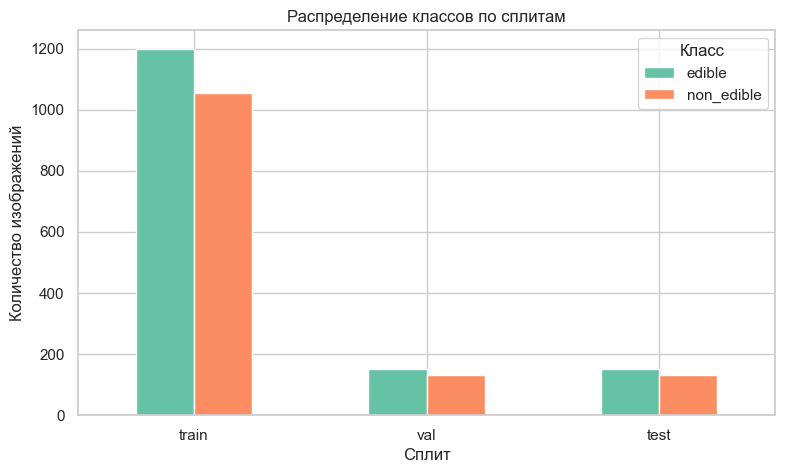

label,edible,non_edible
split,,
train,0.532,0.468
val,0.532,0.468
test,0.532,0.468


In [5]:
plot_df = split_label_counts.drop(columns="total")
ax = plot_df.plot(kind="bar", figsize=(9, 5))
ax.set_title("Распределение классов по сплитам")
ax.set_xlabel("Сплит")
ax.set_ylabel("Количество изображений")
ax.legend(title="Класс")
plt.xticks(rotation=0)
plt.show()

class_share_percent = plot_df.div(plot_df.sum(axis=1), axis=0).round(3)
class_share_percent

## Видовое разнообразие

Имена файлов содержат вид гриба. Это полезно проверить, потому что модель может переобучиться на отдельные виды, если часть видов сильно доминирует.

,label,species,count
0,edible,Agaricus_bisporus,60
1,edible,Agaricus_subrufescens,60
2,edible,Auricularia_auricula-judae,60
3,edible,Boletus_edulis,60
4,edible,Cantharellus_cibarius,60
5,edible,Coprinus_comatus,60
6,edible,Cordyceps_sinensis,60
7,edible,Flammulina_velutipes,60
8,edible,Ganoderma_lucidum,60
9,edible,Grifola_frondosa,60


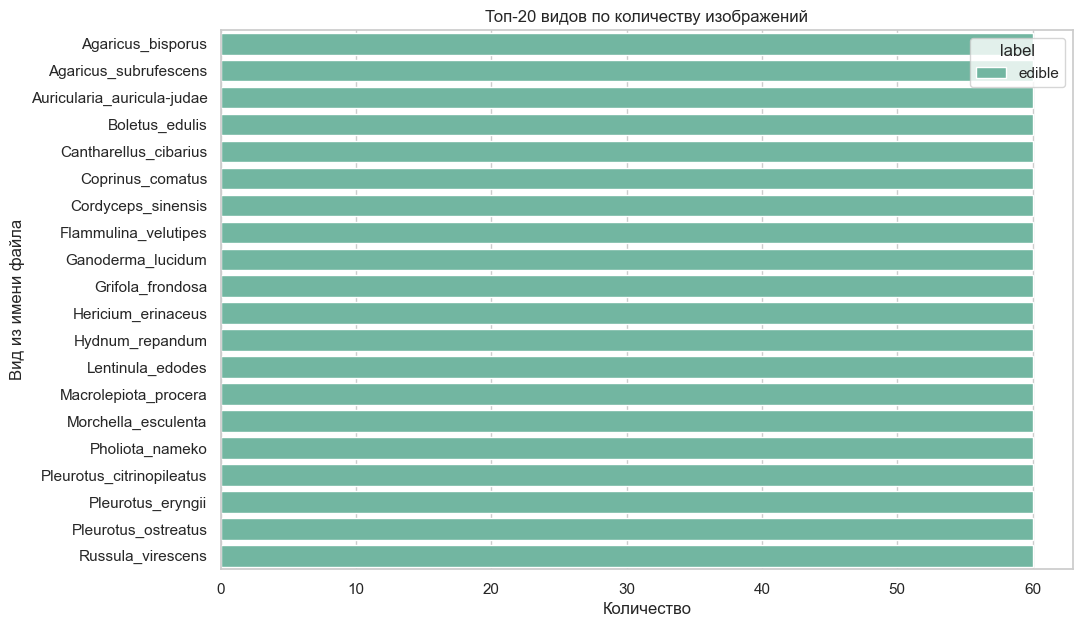

In [6]:
species_counts = (
    eda_df.groupby(["label", "species"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values("count", ascending=False)
)
display(species_counts.head(15))

top_species = species_counts.head(20)
plt.figure(figsize=(11, 7))
sns.barplot(data=top_species, y="species", x="count", hue="label")
plt.title("Топ-20 видов по количеству изображений")
plt.xlabel("Количество")
plt.ylabel("Вид из имени файла")
plt.show()

## Форматы, режимы цвета и битые изображения

На этом шаге ищем неподдерживаемые форматы, битые изображения и различия цветовых режимов. Для обучения все изображения будут приведены к RGB.

In [7]:
display(pd.crosstab(eda_df["image_format"], eda_df["label"], margins=True))
display(pd.crosstab(eda_df["mode"], eda_df["label"], margins=True))

broken_images = eda_df[eda_df["is_broken"]]
print(f"Битых изображений: {len(broken_images)}")
broken_images[["relative_path", "split", "label"]].head(20)

label,edible,non_edible,All
image_format,,,
JPEG,1386,1261,2647
MPO,2,6,8
PNG,108,51,159
WEBP,4,2,6
All,1500,1320,2820


label,edible,non_edible,All
mode,,,
P,24,13,37
RGB,1425,1291,2716
RGBA,51,16,67
All,1500,1320,2820


Битых изображений: 0


,relative_path,split,label


## Размеры изображений

Изображения имеют разные размеры и соотношения сторон, поэтому перед бейзлайном нужен единый размер входа. Для CNN-бейзлайна выбран размер 224x224.

In [8]:
valid_df = eda_df[~eda_df["is_broken"]].copy()
valid_df[["width", "height", "aspect_ratio", "megapixels", "file_size_kb"]].describe().round(2)

,width,height,aspect_ratio,megapixels,file_size_kb
count,2820.00,2820.00,2820.00,2820.00,2820.00
mean,1044.97,869.14,1.27,1.40,439.21
std,821.74,675.80,0.35,3.22,1161.80
min,260.00,260.00,0.44,0.07,7.18
25%,563.00,451.00,1.00,0.26,70.26
50%,850.00,683.00,1.33,0.66,152.00
75%,1200.00,1000.00,1.50,1.08,296.58
max,9312.00,6466.00,4.00,56.02,13809.40


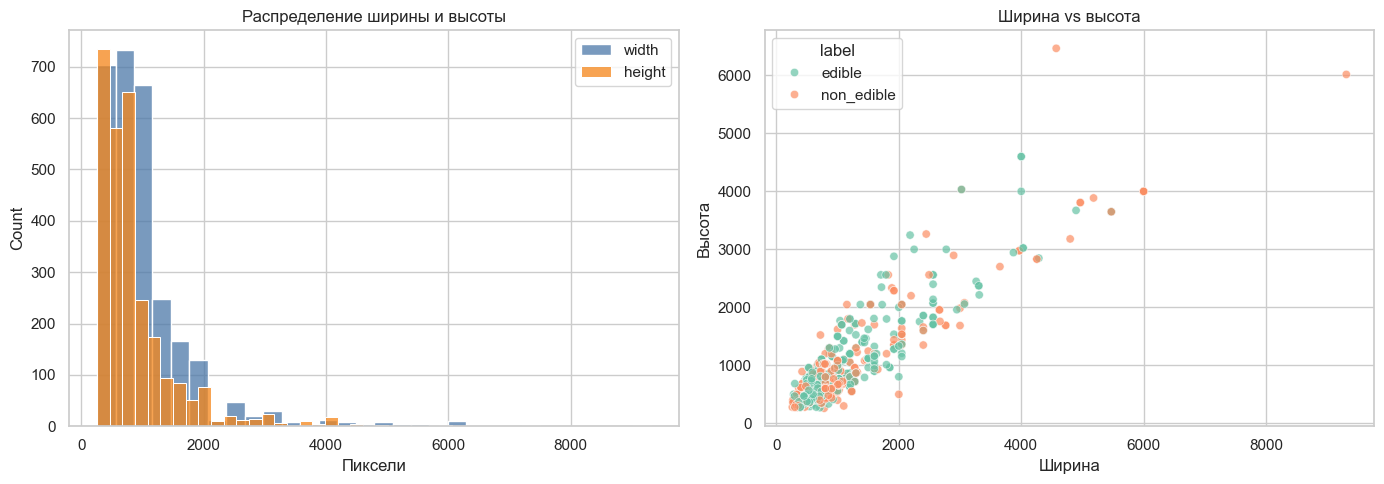

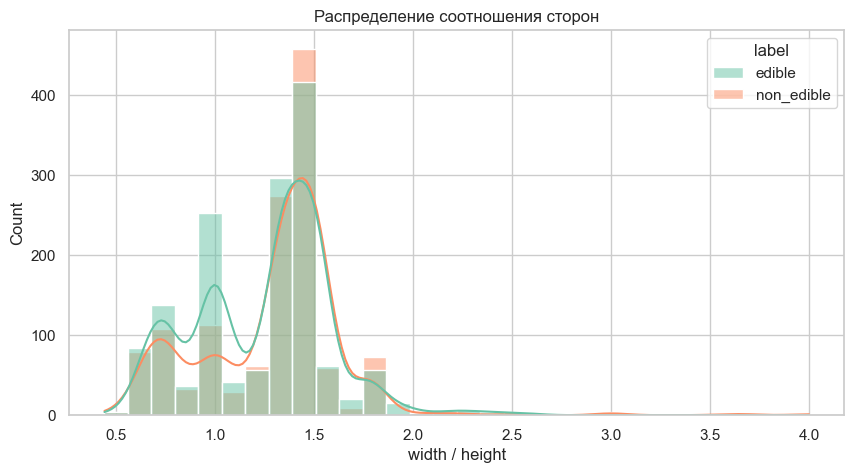

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(valid_df["width"], bins=30, ax=axes[0], color="#4C78A8", label="width")
sns.histplot(valid_df["height"], bins=30, ax=axes[0], color="#F58518", label="height")
axes[0].set_title("Распределение ширины и высоты")
axes[0].set_xlabel("Пиксели")
axes[0].legend()

sns.scatterplot(
    data=valid_df.sample(min(1000, len(valid_df)), random_state=42),
    x="width",
    y="height",
    hue="label",
    alpha=0.7,
    ax=axes[1],
)
axes[1].set_title("Ширина vs высота")
axes[1].set_xlabel("Ширина")
axes[1].set_ylabel("Высота")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(data=valid_df, x="aspect_ratio", hue="label", bins=30, kde=True)
plt.title("Распределение соотношения сторон")
plt.xlabel("width / height")
plt.show()

## Проверка полных дубликатов

Полные дубликаты ищутся по SHA-256 хешу исходного файла. Если один и тот же файл попадает в разные сплиты, это может дать утечку данных и завысить метрики.

In [10]:
duplicates = (
    valid_df.groupby("sha256")
    .agg(
        count=("relative_path", "count"),
        splits=("split", lambda values: sorted(set(values))),
        labels=("label", lambda values: sorted(set(values))),
        examples=("relative_path", lambda values: list(values)[:5]),
    )
    .query("count > 1")
    .sort_values("count", ascending=False)
)

print(f"Групп полных дубликатов: {len(duplicates)}")
display(duplicates.head(20))

cross_split_duplicates = duplicates[duplicates["splits"].apply(len) > 1]
print(f"Групп дубликатов между разными сплитами: {len(cross_split_duplicates)}")
cross_split_duplicates.head(20)

Групп полных дубликатов: 1296


,count,splits,labels,examples
sha256,,,,
5ca110dacdd4860fc4e989020e77f3c03e1f0ed6e73cc7b62781c43241bf202a,6,[train],[non_edible],[data/raw/splitted_dataset/train/poisonous/Ama...
abf937a7ead22fd313a8e686a0487412c59de506e3e14842da2a79df80530c9d,6,[train],[non_edible],[data/raw/splitted_dataset/train/poisonous/Ama...
20095ac39022ae3b7e07d29602c424b6735c0b5a5117b5986e9838a4b6945e09,4,[train],[non_edible],[data/raw/splitted_dataset/train/poisonous/Ama...
37ff51a8d0e370c856513579b7ec48aecf1dd009ec51938dd379121fee970321,4,[train],[edible],[data/raw/splitted_dataset/train/edible/Agaric...
7421bf808e0e5f66014dcb2f7dca9b1a69403492c75105b49c9bfebb6653d6c5,4,[train],[non_edible],[data/raw/splitted_dataset/train/poisonous/Ama...
0a0496323ae6393810316980141edf9018fe3450b72a2f6b217a4181e7c86639,4,"[test, train, val]",[non_edible],[data/raw/splitted_dataset/train/poisonous/Ama...
66eab62ea6be45252f373763ee2a6f73d38eb27d06bbbbed98bfcfe30d8a0418,4,"[train, val]",[non_edible],[data/raw/splitted_dataset/train/poisonous/Ama...
5952db611e76a9ec514d4679b445ff150c276d9c0bb88961981cb8bc43a9c80f,4,"[test, train]",[non_edible],[data/raw/splitted_dataset/train/poisonous/Ama...
27f60fd3709ae13b3aa884d22e61e695d1889d2558997ecc1430e61133f0ccfc,4,"[train, val]",[non_edible],[data/raw/splitted_dataset/train/poisonous/Ama...


Групп дубликатов между разными сплитами: 466


,count,splits,labels,examples
sha256,,,,
0a0496323ae6393810316980141edf9018fe3450b72a2f6b217a4181e7c86639,4,"[test, train, val]",[non_edible],[data/raw/splitted_dataset/train/poisonous/Ama...
66eab62ea6be45252f373763ee2a6f73d38eb27d06bbbbed98bfcfe30d8a0418,4,"[train, val]",[non_edible],[data/raw/splitted_dataset/train/poisonous/Ama...
5952db611e76a9ec514d4679b445ff150c276d9c0bb88961981cb8bc43a9c80f,4,"[test, train]",[non_edible],[data/raw/splitted_dataset/train/poisonous/Ama...
27f60fd3709ae13b3aa884d22e61e695d1889d2558997ecc1430e61133f0ccfc,4,"[train, val]",[non_edible],[data/raw/splitted_dataset/train/poisonous/Ama...
358502e1888763c648149f1d4e7a7d231229941ab1b07de94bfb265368d7a852,4,"[train, val]",[non_edible],[data/raw/splitted_dataset/train/poisonous/Ama...
5d83ebcd94ca2248125016465f4319f2306c076118b58b7e2ecfaff7368698ed,4,"[train, val]",[non_edible],[data/raw/splitted_dataset/train/poisonous/Ama...
fe5e840ca2ab2fe6a213d98f92abc9002682a2c16c9ac633ece22894721fd53e,4,"[train, val]",[non_edible],[data/raw/splitted_dataset/train/poisonous/Ama...
9089e9e2a16977ea8e2e9dfceda9faba1709af09437e57fd5b16c761e2a78bfc,4,"[test, train, val]",[non_edible],[data/raw/splitted_dataset/train/poisonous/Ama...
9af8a147f5f9bf25bfbf47d99529f93c9fc4f6b05525410d2865f9635e6c5601,4,"[test, train, val]",[non_edible],[data/raw/splitted_dataset/train/poisonous/Ama...


## Визуальная проверка примеров

Смотрим случайные изображения из каждого класса и сплита. Это помогает заметить шум, водяные знаки, нерелевантные картинки, сильные различия фона и другие артефакты.

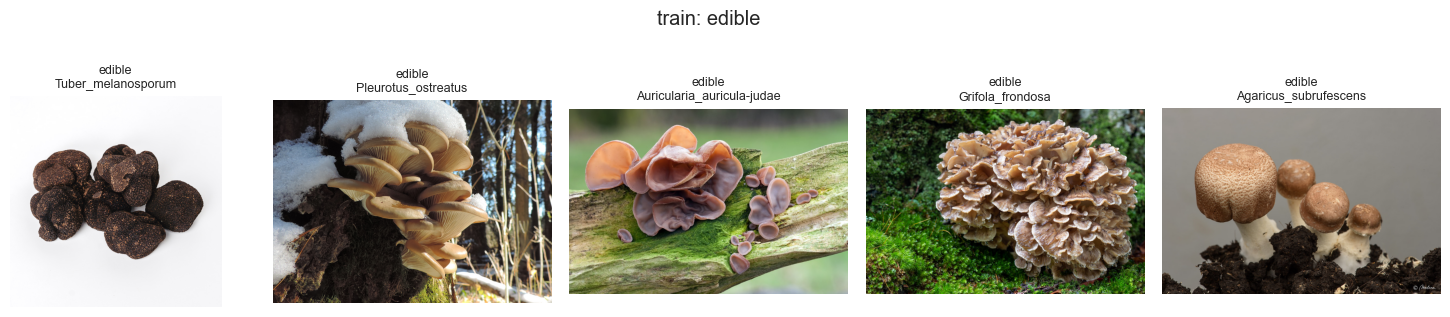

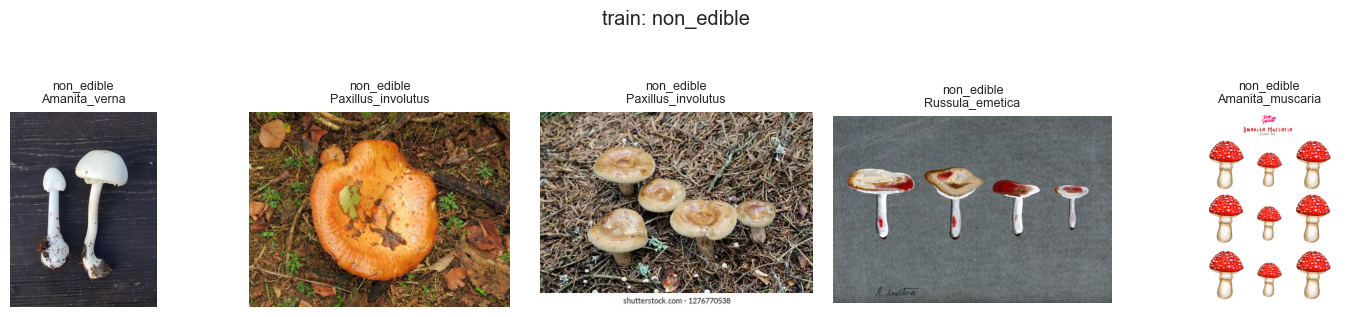

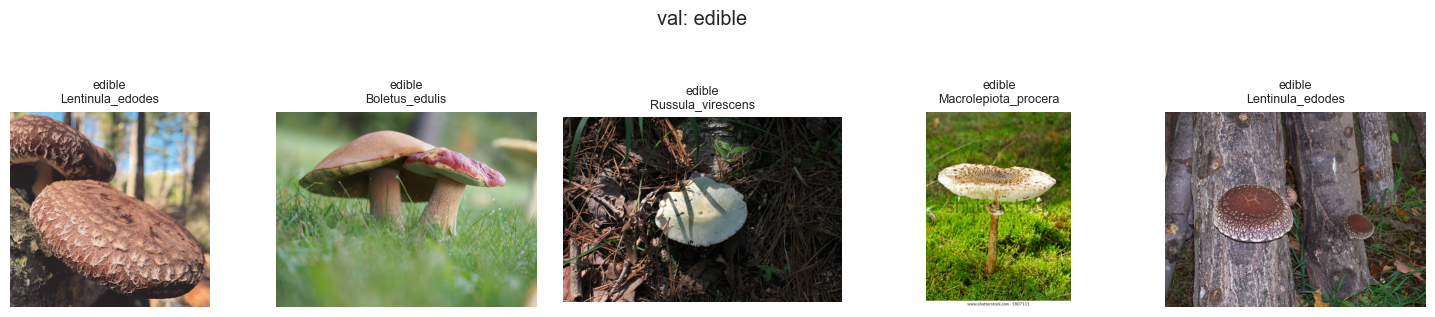

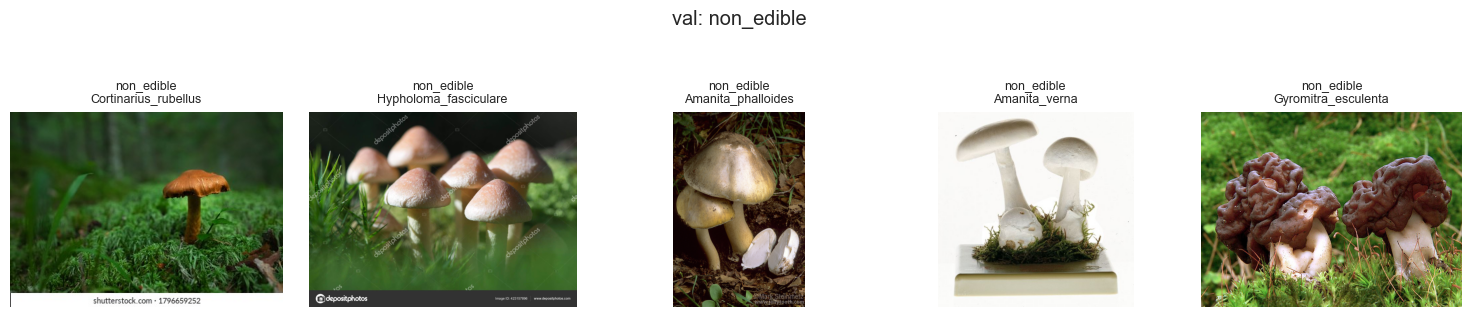

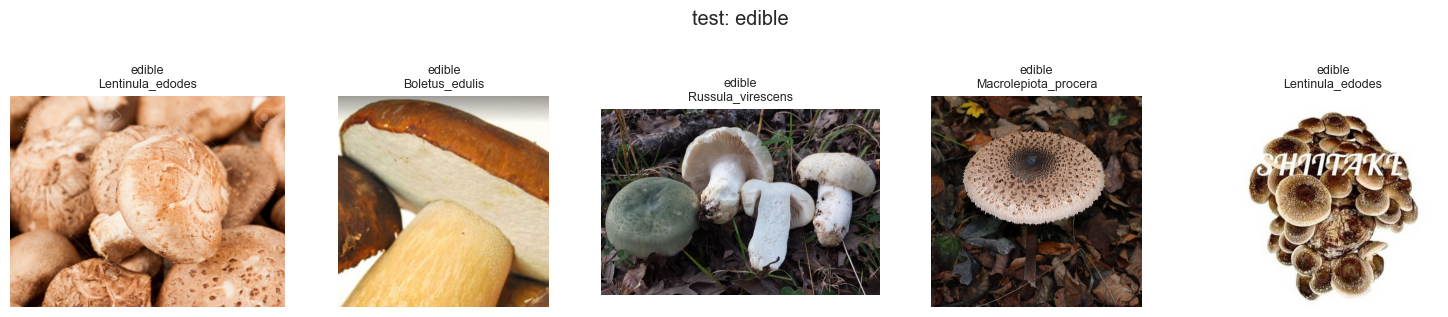

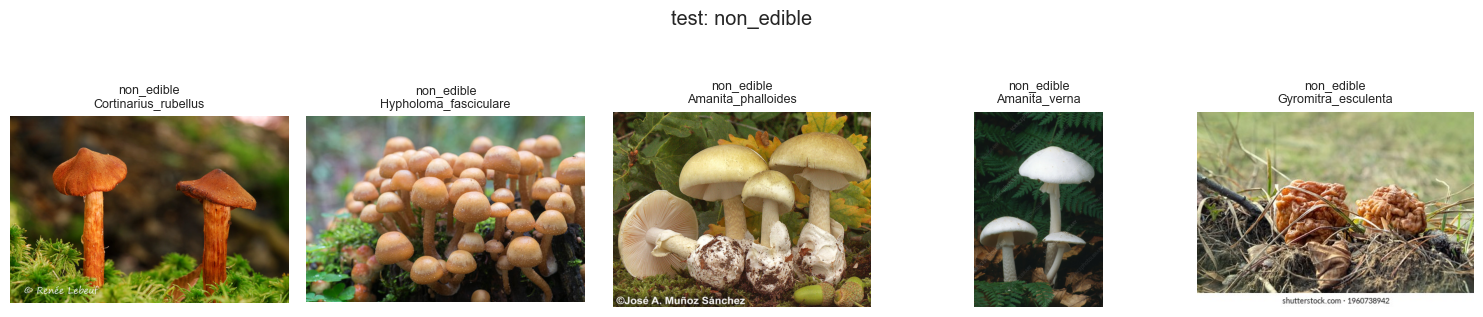

In [11]:
def show_samples(df: pd.DataFrame, split: str, label: str, n: int = 5) -> None:
    subset = df[(df["split"] == split) & (df["label"] == label) & (~df["is_broken"])]
    if subset.empty:
        print(f"Нет изображений для {split=} и {label=}")
        return

    sample = subset.sample(n=min(n, len(subset)), random_state=42)

    fig, axes = plt.subplots(1, len(sample), figsize=(3 * len(sample), 3))
    if len(sample) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, sample.iterrows()):
        with Image.open(row["path"]) as image:
            ax.imshow(image.convert("RGB"))
        ax.set_title(f"{row['label']}\n{row['species']}", fontsize=9)
        ax.axis("off")

    fig.suptitle(f"{split}: {label}", y=1.05)
    plt.tight_layout()
    plt.show()


for split in SPLITS:
    for label in ["edible", "non_edible"]:
        show_samples(eda_df, split=split, label=label, n=5)

## Препроцессинг для бейзлайна

Для дальнейшего обучения используется скрипт `src/data/prepare_dataset.py`. Он выполняет ETL-часть для изображений:

- Extract: читает файлы из `data/raw/splitted_dataset/train|val|test/edible|poisonous`;
- Transform: проверяет читаемость, переводит в RGB, приводит к 224x224, сохраняет пропорции через padding, переименовывает `poisonous` в `non_edible`;
- Load: сохраняет результат в `data/processed`, а также пишет `manifest.csv`, манифесты по сплитам и `dataset_metadata.json`.

Сначала можно выполнить сухую проверку без записи файлов:

```bash
python src/data/prepare_dataset.py --dry-run
```

Команда для создания обработанного датасета:

```bash
python src/data/prepare_dataset.py --overwrite
```

После подготовки структура будет такой:

```text
data/processed/
├── train/
│   ├── edible/
│   └── non_edible/
├── val/
│   ├── edible/
│   └── non_edible/
├── test/
│   ├── edible/
│   └── non_edible/
├── manifest.csv
├── train_manifest.csv
├── val_manifest.csv
├── test_manifest.csv
└── dataset_metadata.json
```

## Выводы EDA

1. Датасет уже разделён на `train`, `val` и `test`, поэтому для бейзлайна не нужно заново делать split.
2. Классы представлены как `edible` и `poisonous`; в проектной постановке `poisonous` лучше нормализовать в `non_edible`.
3. Перед обучением нужно привести изображения к единому размеру и RGB-формату.
4. Для отчёта и защиты стоит явно показать баланс классов, размеры изображений, форматы, визуальные примеры и результат проверки дубликатов.
5. Для метрик бейзлайна особенно важен recall по классу `non_edible`, потому что пропуск несъедобного гриба является наиболее опасным типом ошибки.